In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, LassoCV
import warnings
from functions import data_quality_analysis, plot_distributions, initial_transform, detect_outliers_iqr, tranform_final
warnings.filterwarnings('ignore')

# Cargar de datos y vista inicial

In [2]:
data = pd.read_excel('imdb_anime.xlsx')
data.shape

(45717, 13)

In [3]:
data.head()

,Title,Genre,User Rating,Number of Votes,Runtime,Year,Summary,Stars,Certificate,Metascore,Gross,Episode,Episode Title
0,One Piece,"Animation, Action, Adventure",8.9,187689,24 min,(1999– ),Follows the adventures of Monkey D. Luffy and ...,"Mayumi Tanaka,Laurent Vernin,Akemi Okamura,Ton...",TV-14,NaN,187689,0,NaN
1,Teenage Mutant Ninja Turtles: Mutant Mayhem,"Animation, Action, Adventure",7.4,28895,99 min,-2023,The film follows the Turtle brothers as they w...,NaN,PG,74,28895,0,NaN
2,The Super Mario Bros. Movie,"Animation, Adventure, Comedy",7.1,189108,92 min,-2023,A plumber named Mario travels through an under...,NaN,PG,46,189108,0,NaN
3,Attack on Titan,"Animation, Action, Adventure",9.1,434457,24 min,(2013–2023),After his hometown is destroyed and his mother...,"Josh Grelle,Bryce Papenbrook,Yûki Kaji,Yui Ish...",TV-MA,NaN,434457,0,NaN
4,Jujutsu Kaisen,"Animation, Action, Adventure",8.5,82909,24 min,(2020– ),A boy swallows a cursed talisman - the finger ...,"Junya Enoki,Yûichi Nakamura,Adam McArthur,Yuma...",TV-MA,NaN,82909,0,NaN


# Análisis de calidad de datos

In [4]:
# Invocación de la función 'data_quality_analysis()'
analysis_result = data_quality_analysis(data).set_index('Columna')
analysis_result

,Tipo de dato,Valores únicos,Valores faltantes
Columna,,,
Title,object,9851,0.000000
Genre,object,201,0.000000
User Rating,object,87,0.452961
Number of Votes,object,3033,0.452961
Runtime,object,196,0.288033
Year,object,740,0.002756
Summary,object,22588,0.484940
Stars,object,6460,0.700855
Certificate,object,33,0.372356


In [5]:
# Se eliminan por exceso de valores faltantes
drop_nan = analysis_result.loc[analysis_result['Valores faltantes']>0.5].index.to_list()
# Se eliminan por no entregar información
drop_noinfo = analysis_result.loc[analysis_result['Valores únicos']==1].index.to_list()
# Se eliminan por exceso de categorias -> no entregan información generalizable
drop_cats = analysis_result.loc[((analysis_result['Valores únicos']/data.shape[0])>0.5)&(analysis_result['Tipo de dato']=='object')].index.to_list()

drop_quality = set(drop_cats + drop_nan + drop_noinfo)
print(drop_quality)

{'Metascore', 'Episode Title', 'Stars'}


In [6]:
# Luego de una primera limpieza, se vuelve a invocar a la función 'data_quality_analysis()'
analysis_result_pos_quality = data_quality_analysis(data.drop(drop_quality, axis=1)).set_index('Columna')
analysis_result_pos_quality

,Tipo de dato,Valores únicos,Valores faltantes
Columna,,,
Title,object,9851,0.000000
Genre,object,201,0.000000
User Rating,object,87,0.452961
Number of Votes,object,3033,0.452961
Runtime,object,196,0.288033
Year,object,740,0.002756
Summary,object,22588,0.484940
Certificate,object,33,0.372356
Gross,object,3033,0.452961


In [7]:
data_quality = data.drop(drop_quality, axis=1)

# Análisis exploratorio inicial

## Distribuciones

In [8]:
columns_distributions = ['Title', 'User Rating', 'Number of Votes', 'Runtime', 'Year', 'Certificate', 'Gross', 'Episode']

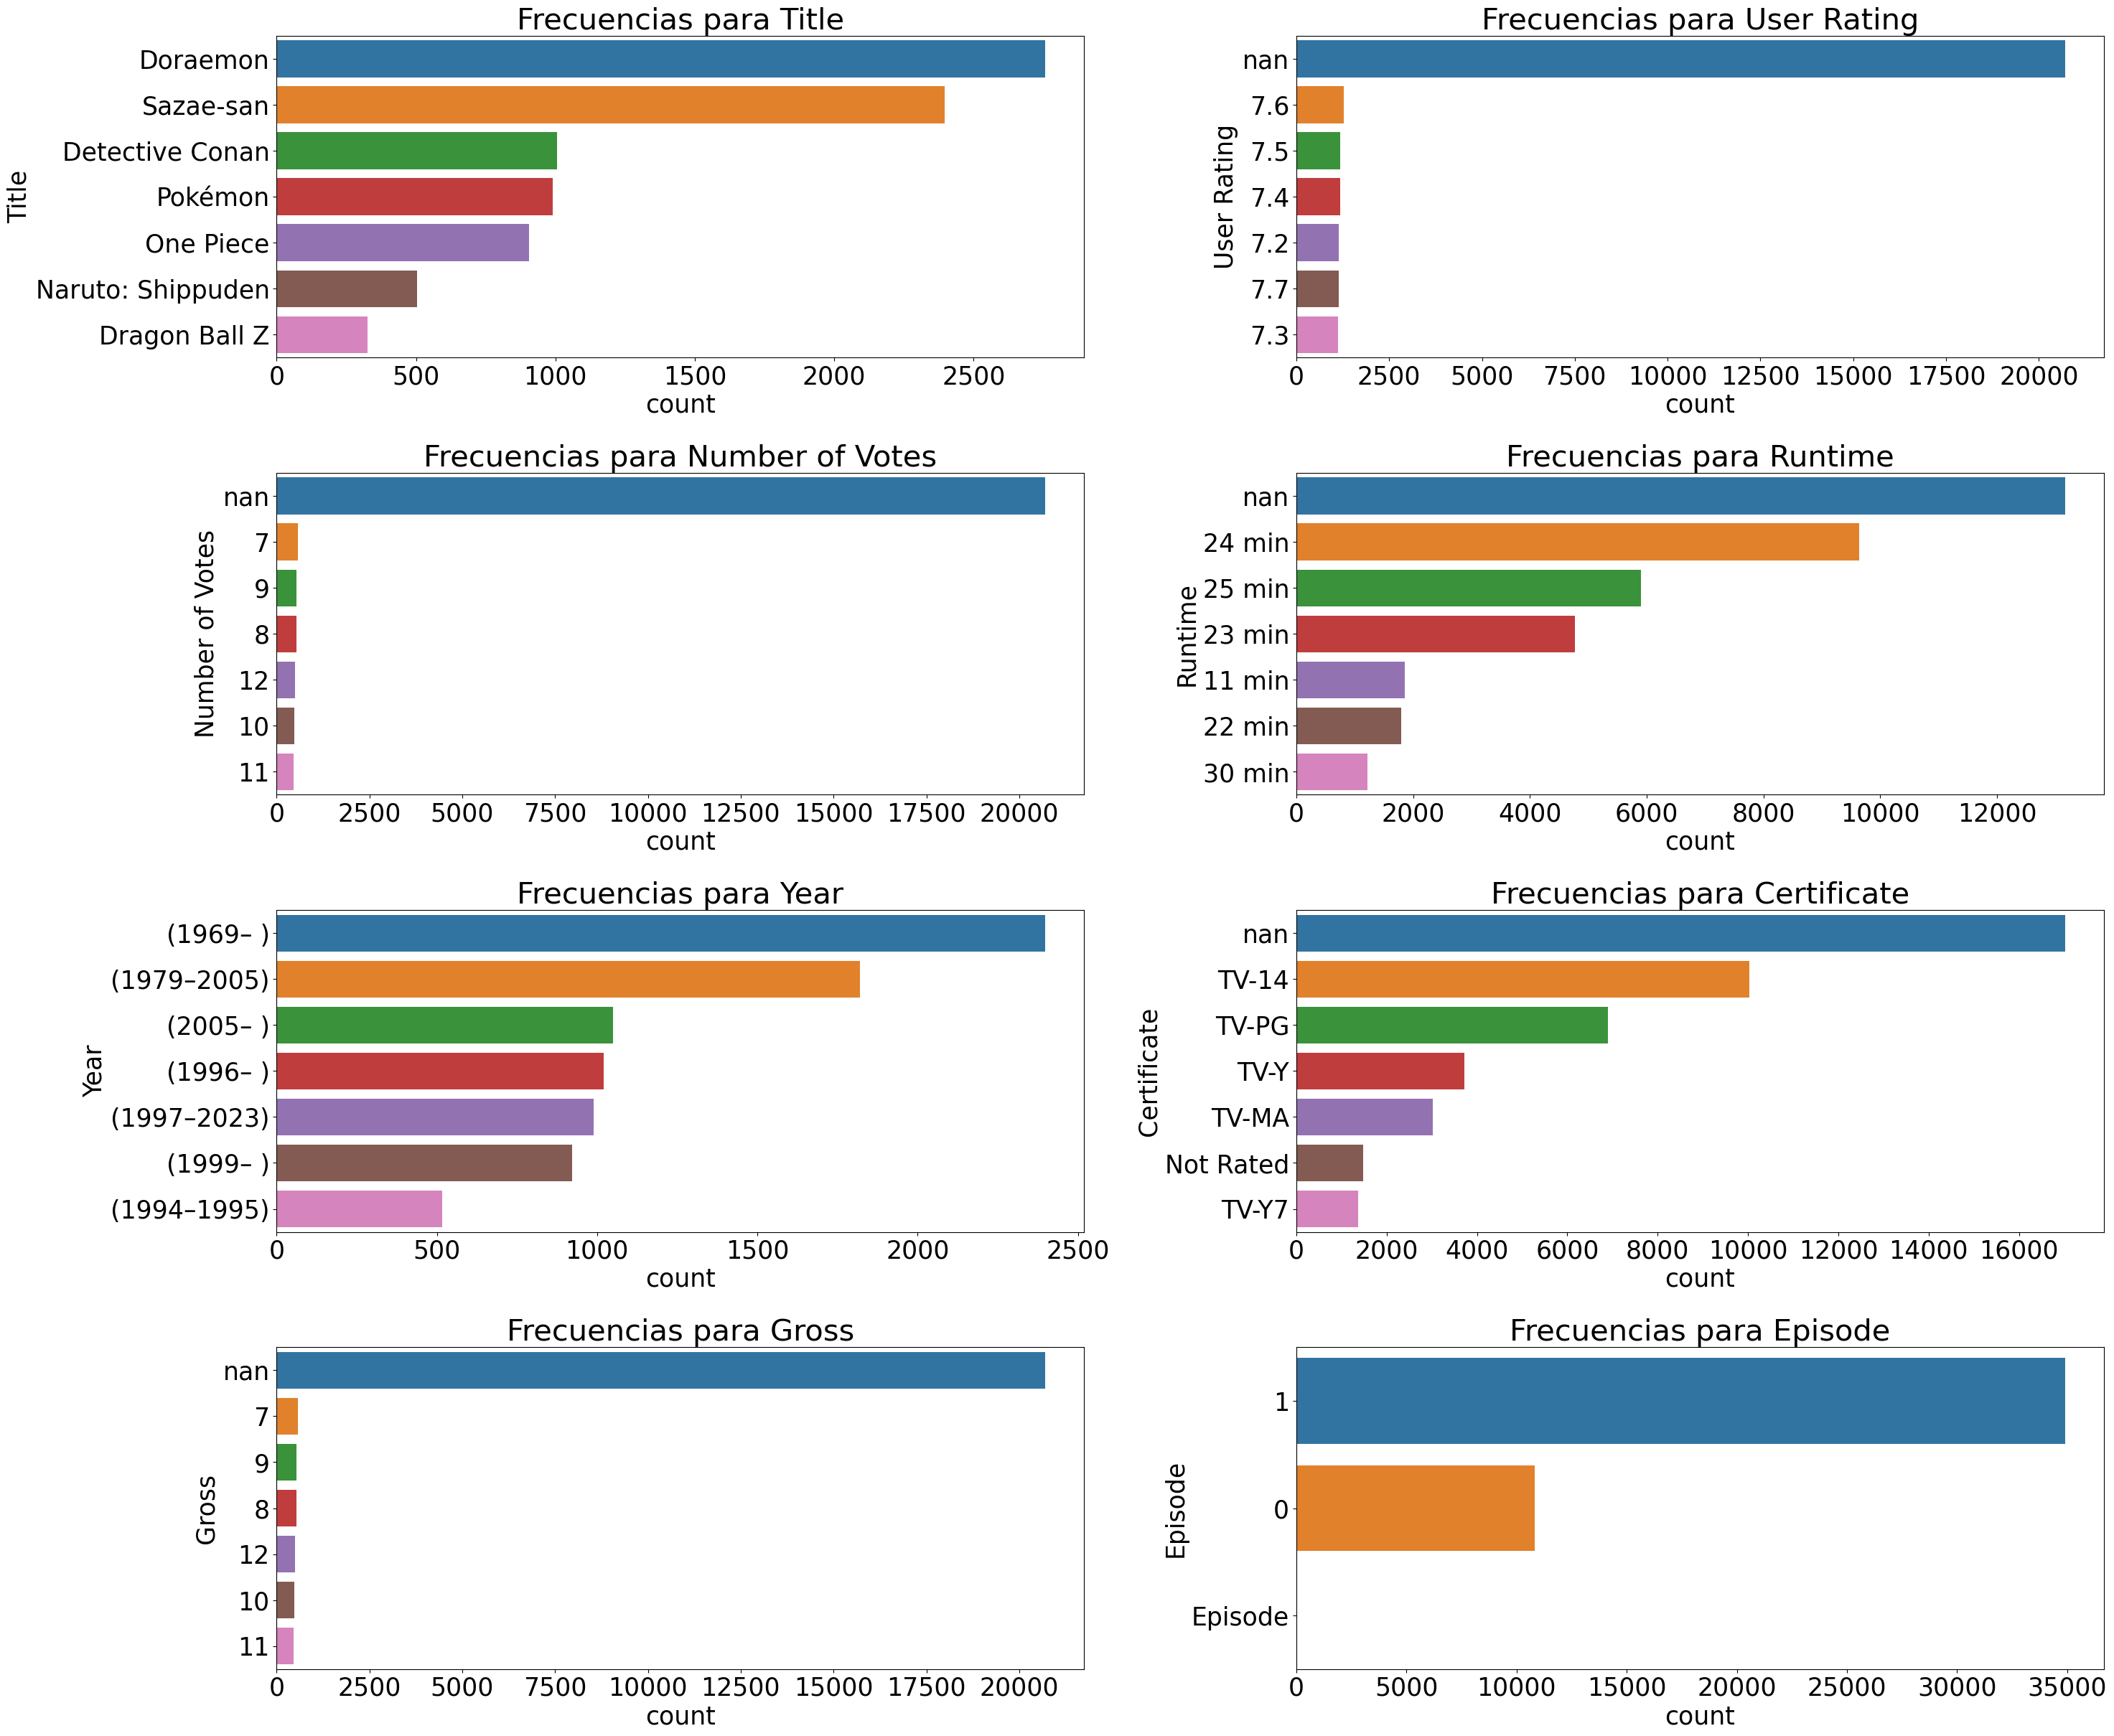

In [9]:
plot_distributions(data_quality, analysis_result, columns_review=columns_distributions)

# Transformaciones iniciales de datos 

In [10]:
data_transform = initial_transform(data_quality)
data_transform.shape

(45717, 9)

In [11]:
analysis_result_transform = data_quality_analysis(data_transform).set_index('Columna')

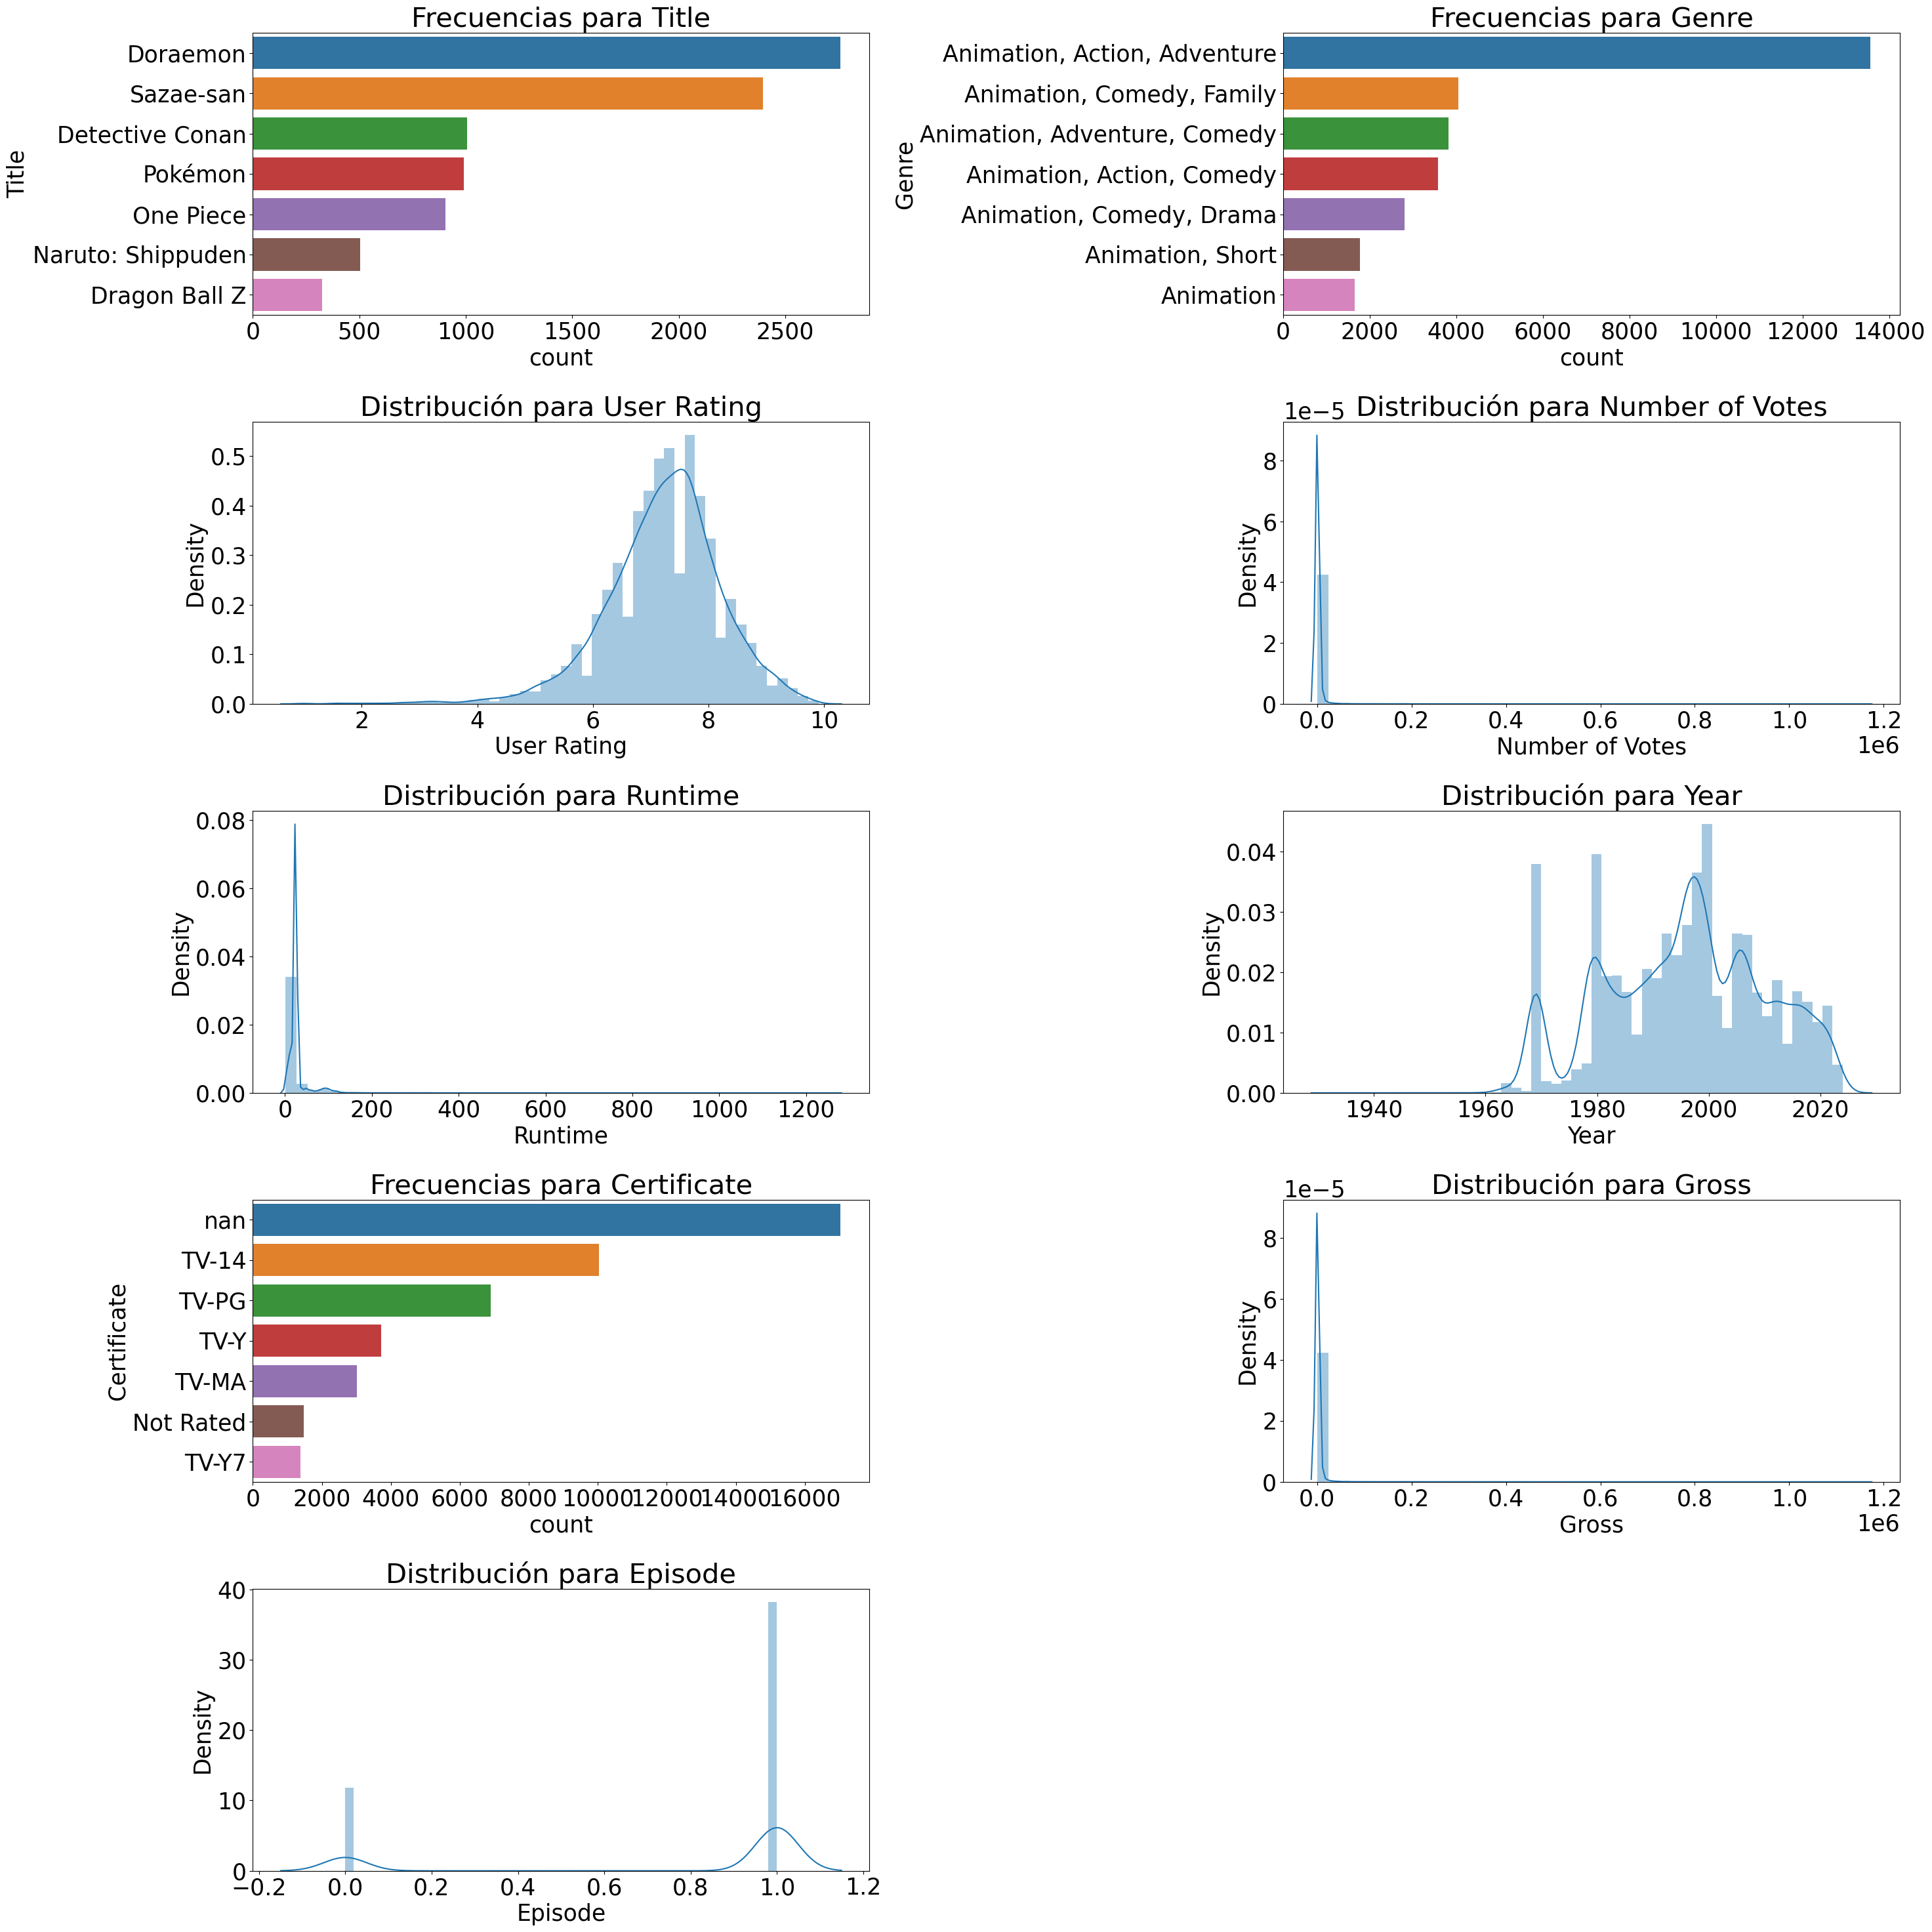

In [12]:
plot_distributions(data_transform, analysis_result_transform, columns_review=None)

# Búsqueda de outliers - IQR

In [13]:
df_outliers, idx_outs = detect_outliers_iqr(data_transform, ['User Rating', 'Number of Votes', 'Runtime', 'Gross'], factor=2)
df_outliers

,lower_bound,upper_bound,q,count,mean,std,min,25%,50%,75%,max
User Rating,4.5,10.0,339.0,25008.0,7.218522,1.002846,1.0,6.7,7.3,7.8,9.9
Number of Votes,-760.0,1195.0,3264.0,25008.0,2983.802143,31682.381039,5.0,22.0,84.0,413.0,1162284.0
Runtime,19.0,29.0,8671.0,32548.0,27.494654,27.578400,1.0,23.0,24.0,25.0,1271.0
Gross,-760.0,1195.0,3264.0,25008.0,2983.802143,31682.381039,5.0,22.0,84.0,413.0,1162284.0


In [14]:
data_transform_clean = data_transform.loc[~data_transform.index.isin(idx_outs)]

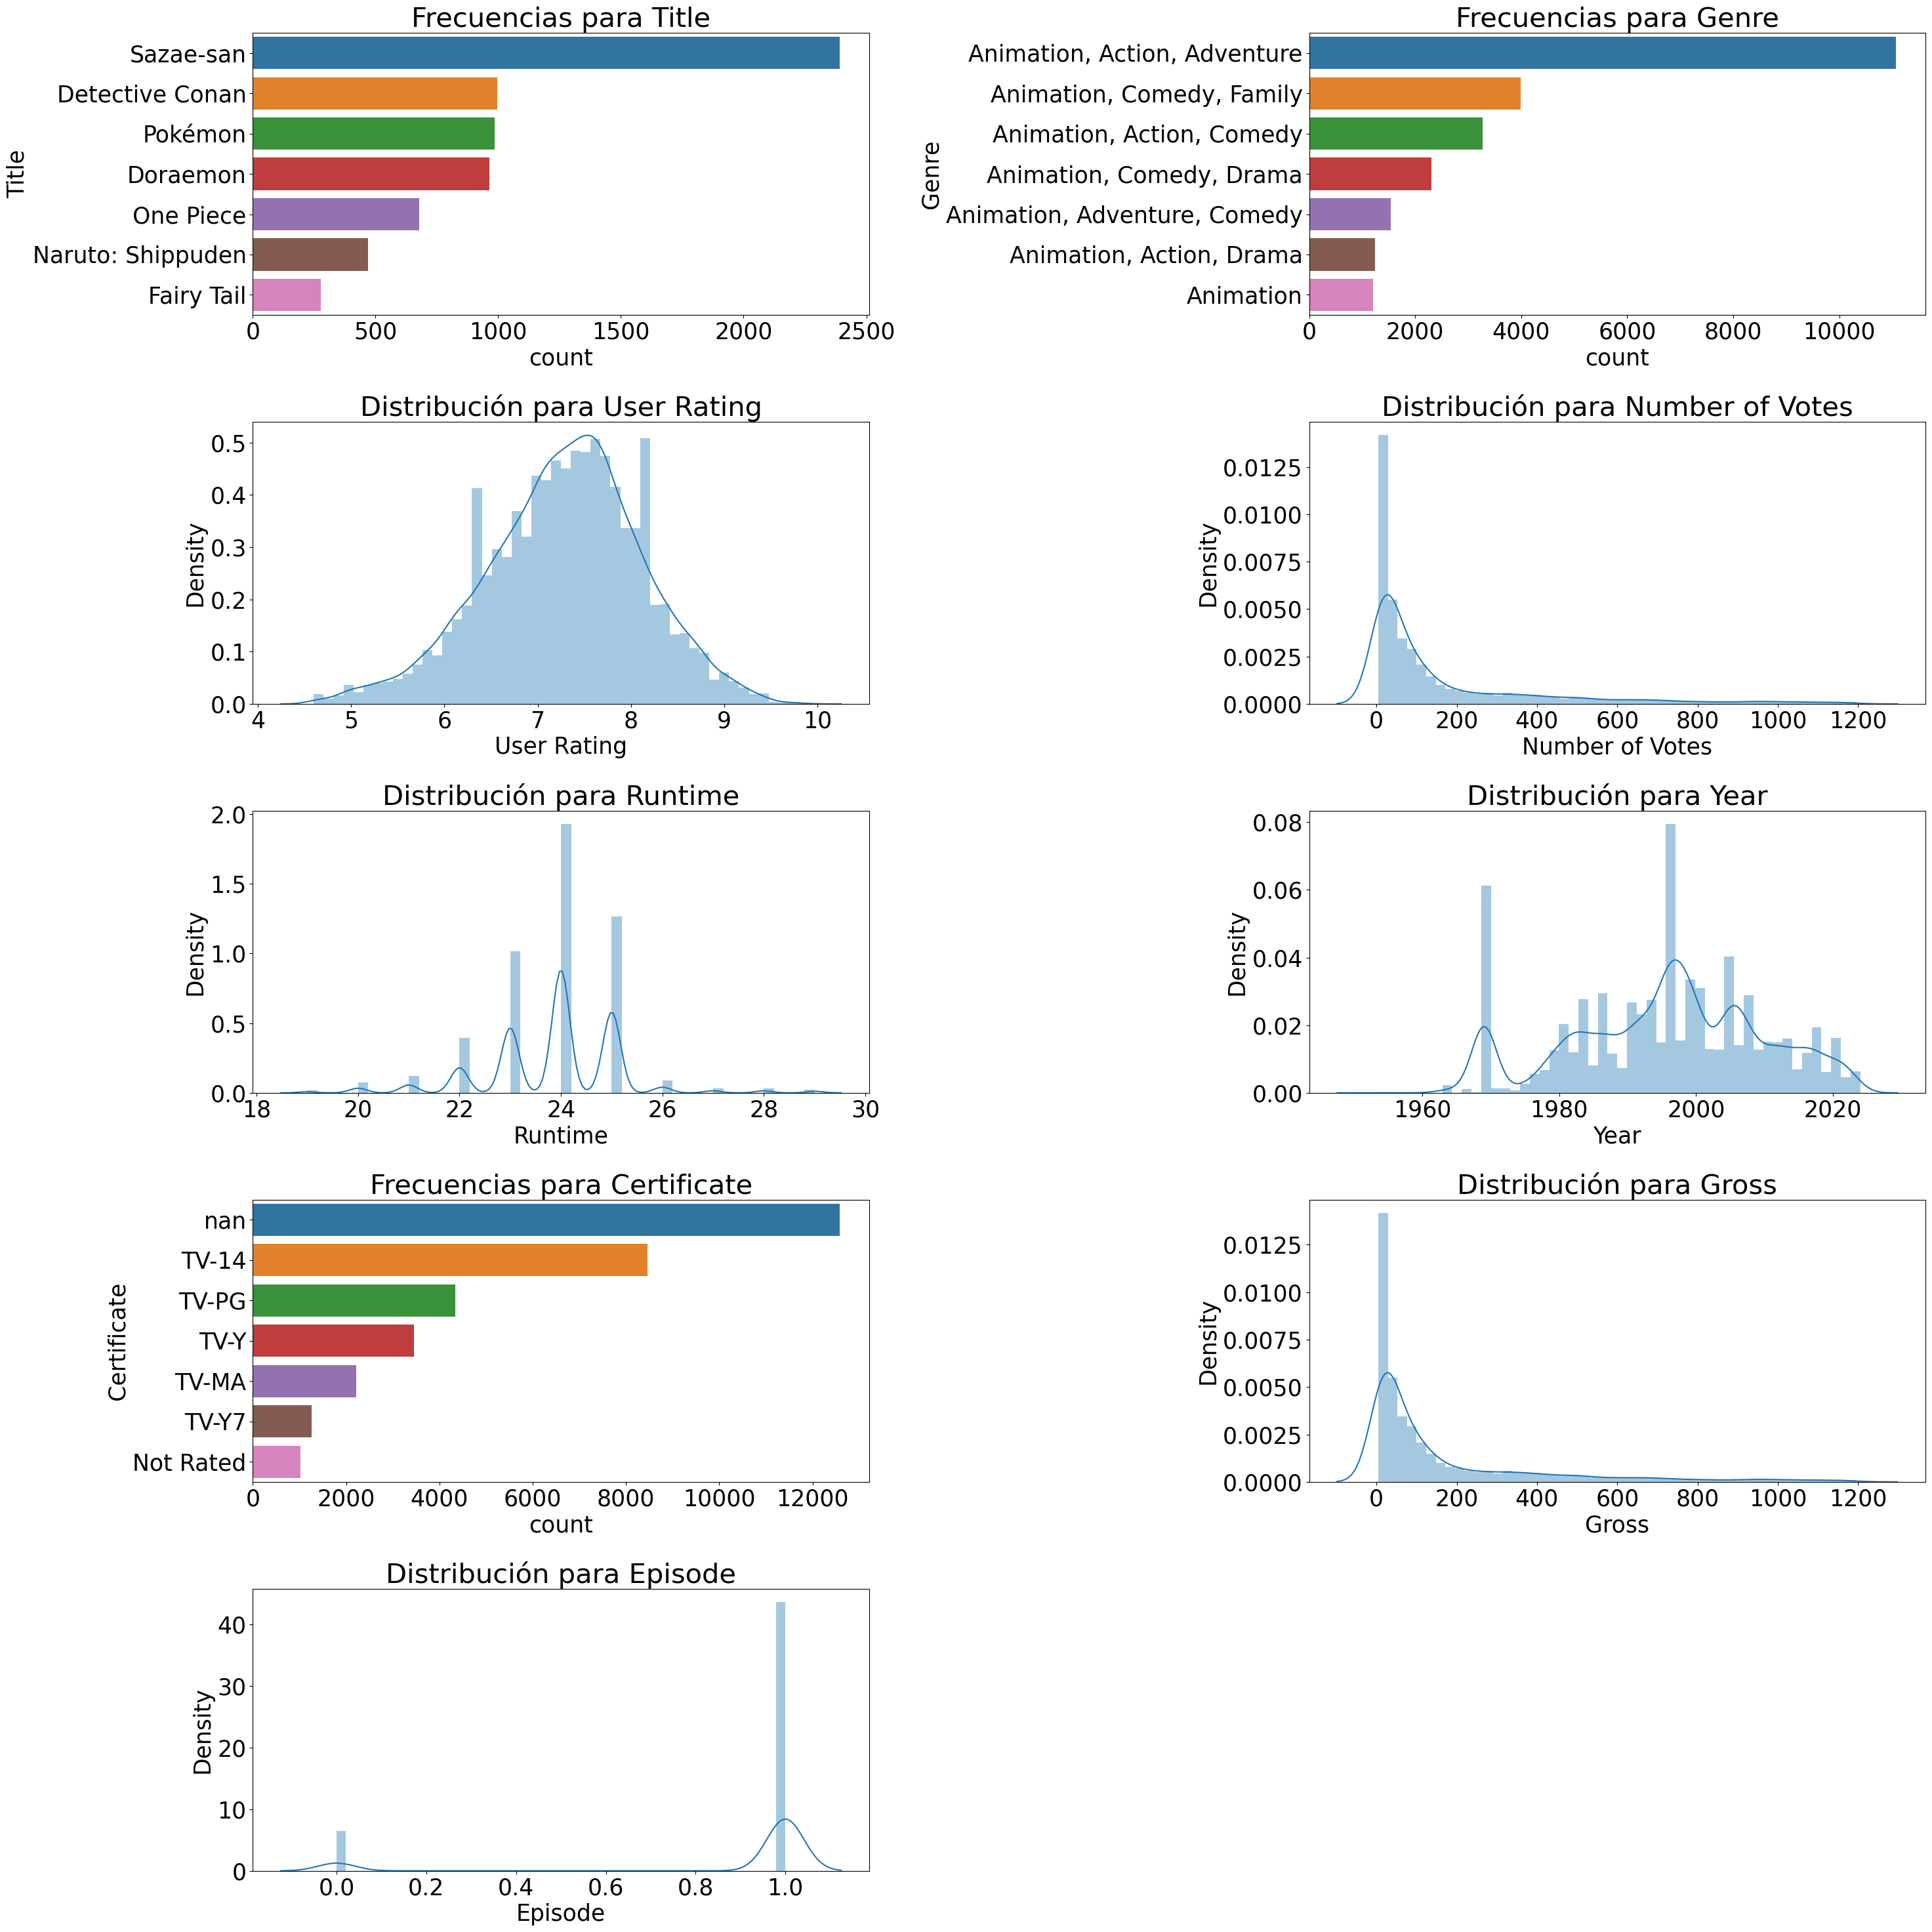

In [15]:
plot_distributions(data_transform_clean, analysis_result_transform, columns_review=None)

# Transformaciones finales  y creación de variables

In [16]:
data_final = tranform_final(data_transform_clean)

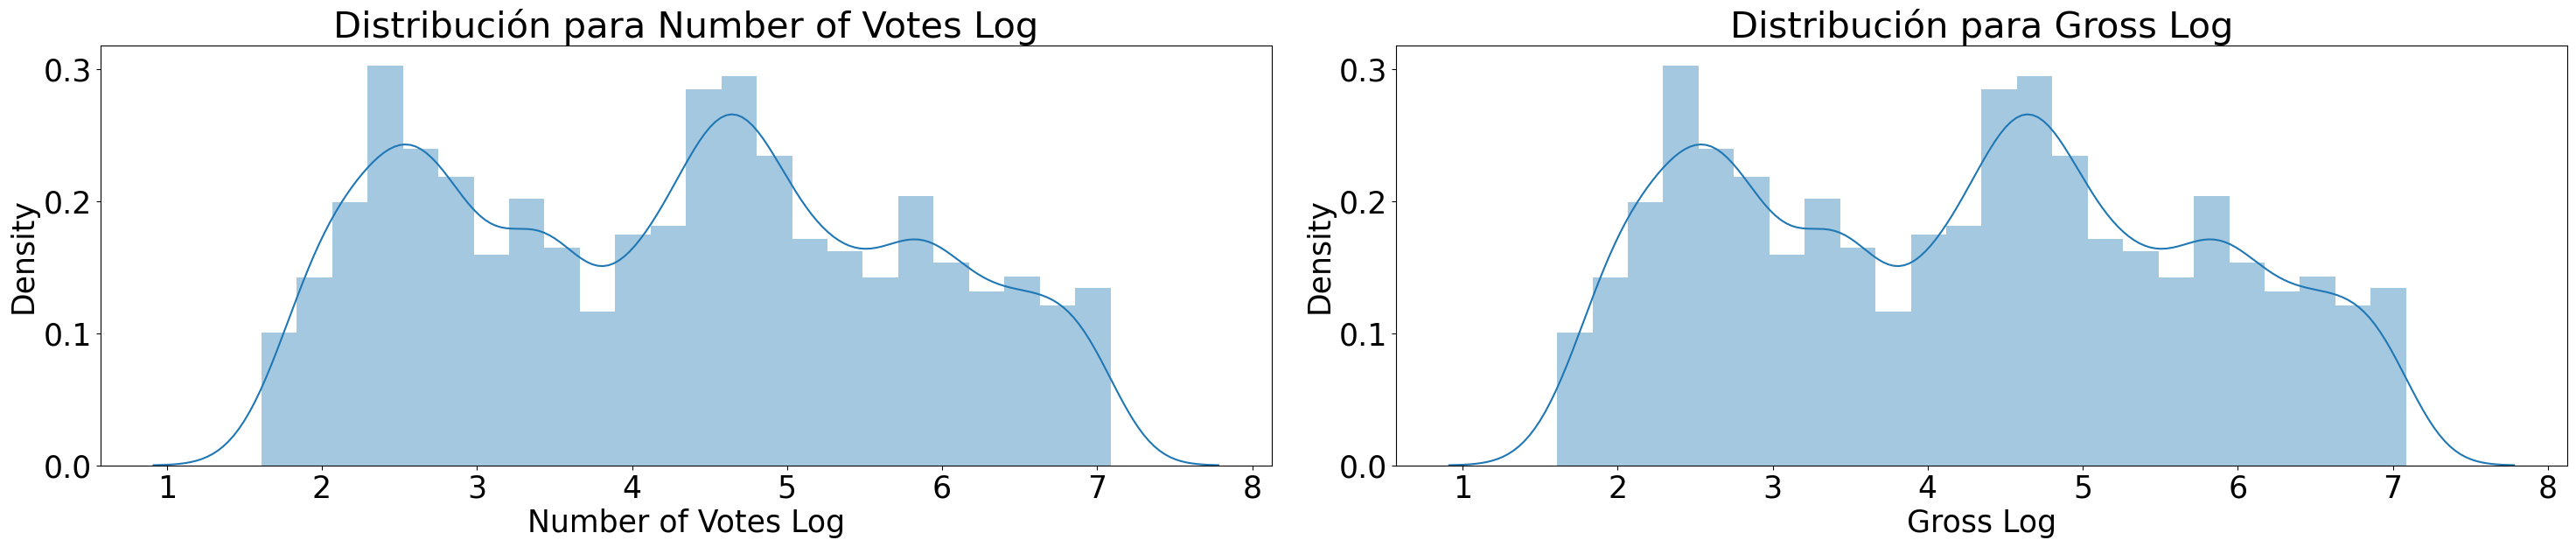

In [17]:
analysis_result_final = data_quality_analysis(data_final).set_index('Columna')
plot_distributions(data_final, analysis_result_final, columns_review=['Number of Votes Log', 'Gross Log'])

# Análisis exploratorio - Correlaciones

In [18]:
correlaciones_pearson = data_final.iloc[:, 1:].corr()

correlaciones_rating = correlaciones_pearson[['User Rating']].abs().sort_values('User Rating', ascending=False)

<Axes: >

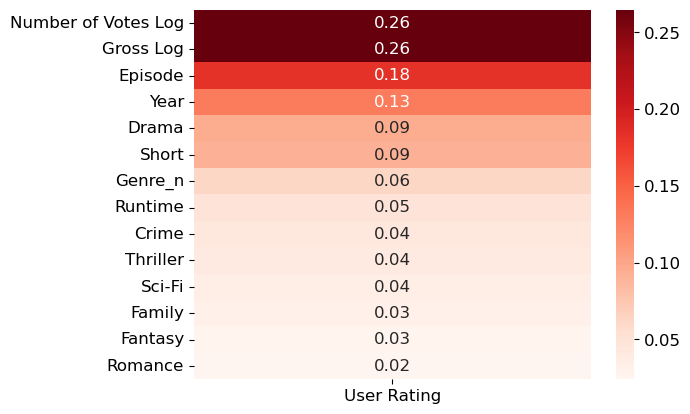

In [19]:
plt.rcParams.update({'font.size': 12})
sns.heatmap(correlaciones_rating[1:15], cmap='Reds', annot=True, annot_kws={'size':12}, fmt=".2f")


<Axes: xlabel='Gross Log', ylabel='User Rating'>

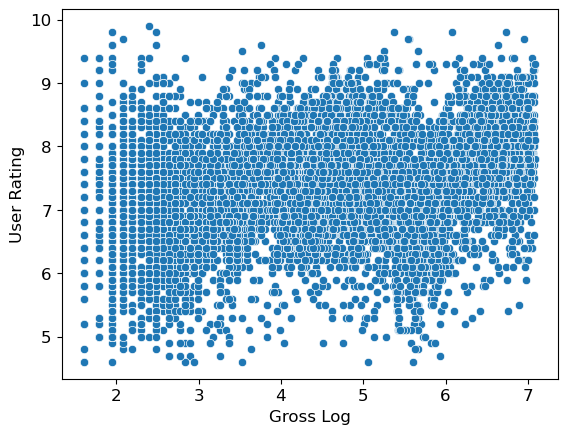

In [20]:
plt.rcParams.update({'font.size': 12})
sns.scatterplot(data=data_final, x='Gross Log', y='User Rating')

<Axes: xlabel='Number of Votes Log', ylabel='User Rating'>

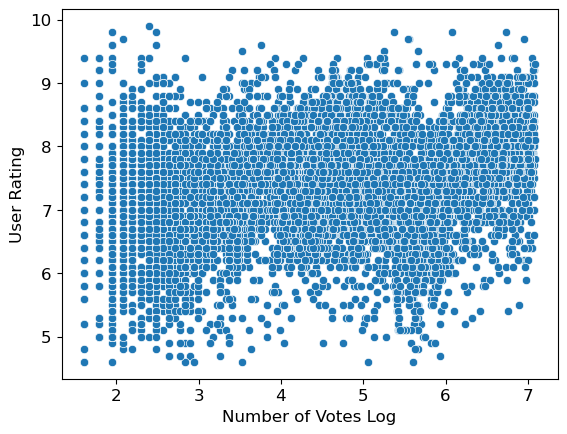

In [21]:
plt.rcParams.update({'font.size': 12})
sns.scatterplot(data=data_final, x='Number of Votes Log', y='User Rating')

<Axes: xlabel='Episode', ylabel='User Rating'>

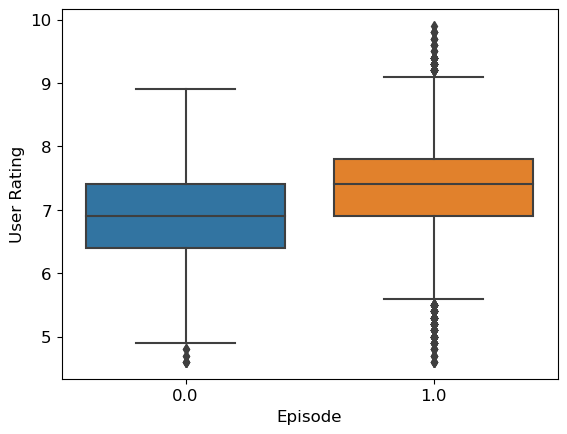

In [22]:
plt.rcParams.update({'font.size': 12})
sns.boxplot(data=data_final, x='Episode', y='User Rating')

# Función de procesamiento de datos desde el inicio

In [23]:
def etl_process_imdb_anime(data_input, columns, factor=1.5):
    data = data_input.copy()
    analysis_result = data_quality_analysis(data).set_index('Columna')

    # Se eliminan por exceso de valores faltantes
    drop_nan = analysis_result.loc[analysis_result['Valores faltantes'] > 0.5].index.to_list()
    # Se eliminan por no entregar información
    drop_noinfo = analysis_result.loc[analysis_result['Valores únicos'] == 1].index.to_list()
    # Se eliminan por exceso de categorías
    drop_cats = analysis_result.loc[((analysis_result['Valores únicos'] / data.shape[0]) > 0.5) & (analysis_result['Tipo de dato'] == 'object')].index.to_list()

    drop_quality = set(drop_cats + drop_nan + drop_noinfo)
    data_quality = data.drop(drop_quality, axis=1)

    data_quality= initial_transform(data_quality)

    df_outliers, idx_outs = detect_outliers_iqr(data_quality, columns, factor) 
    # Se eliminan outliers
    data_transform_clean = data_quality.loc[~data_quality.index.isin(idx_outs)]

    data_output = tranform_final(data_transform_clean)

    return data_output


In [ ]:
data = pd.read_excel('imdb_anime.xlsx')
data_final = etl_process_imdb_anime(data, ['Number of Votes', 'Runtime', 'Gross'])

In [25]:
data_final.sample(10)

,Title,User Rating,Runtime,Year,Episode,Genre_n,Number of Votes Log,Gross Log,Action,Adventure,...,Musical,Mystery,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western
1164,Love Hina,7.6,23.0,2000.0,1.0,3,3.044522,3.044522,0,0,...,0,0,0,0,0,0,0,0,0,0
7330,Inuyasha,7.7,25.0,2000.0,1.0,3,4.584967,4.584967,1,1,...,0,0,0,0,0,0,0,0,0,0
1051,Sailor Moon,7.6,24.0,1992.0,1.0,3,4.143135,4.143135,1,1,...,0,0,0,0,0,0,0,0,0,0
7732,Seinto Seiya: The Lost Canvas - Meio Shinwa,7.8,25.0,2009.0,1.0,3,4.744932,4.744932,1,1,...,0,0,0,0,0,0,0,0,0,0
4808,Cat's Eye,7.2,24.0,1983.0,1.0,3,2.302585,2.302585,1,1,...,0,0,0,0,0,0,0,0,0,0
8730,Sword Art Online,7.2,23.0,2012.0,1.0,3,5.988961,5.988961,1,1,...,0,0,0,0,0,0,0,0,0,0
1368,Mobile Suit Gundam Seed,7.3,23.0,2002.0,1.0,3,3.178054,3.178054,1,1,...,0,0,0,0,0,0,0,0,0,0
9310,High School DxD,7.9,25.0,2012.0,1.0,3,5.552960,5.552960,1,0,...,0,0,0,0,0,0,0,0,0,0
9074,Haikyu!!,7.9,24.0,2014.0,1.0,3,6.192362,6.192362,0,0,...,0,0,0,0,0,0,0,0,0,0
3550,Sailor Moon,8.6,23.0,1992.0,1.0,3,4.488636,4.488636,1,1,...,0,0,0,0,0,0,0,0,0,0


# Selección de variables

## Correlaciones

In [26]:
numeric_features = data_final.select_dtypes(include=[np.number]).columns.tolist()

In [27]:
correlaciones_pearson = data_final.loc[:,numeric_features].corr()

correlacion_Vs_target = correlaciones_pearson.loc[:, ['User Rating']].sort_values('User Rating', ascending=False)

selected_features_correlations = correlacion_Vs_target[abs(correlacion_Vs_target).iloc[1:]>=0.045].dropna().index
selected_features_correlations

Index(['Number of Votes Log', 'Gross Log', 'Episode', 'Year', 'Action',
       'Genre_n', 'Short'],
      dtype='object')

## Forward

In [ ]:
features = data_final.drop(['Title', 'User Rating'], axis=1)
target = data_final.loc[:, ['User Rating']]

In [ ]:
# Se crea un modelo base
base_model = LinearRegression()

sfs = SequentialFeatureSelector(base_model, n_features_to_select=7, direction='forward', scoring='neg_mean_absolute_percentage_error', cv=5)
sfs.fit(features, target)
selected_features_Forward = features.columns[sfs.support_]
print("Características seleccionadas por Forward Selection:")
print(selected_features_Forward)

Características seleccionadas por Forward Selection:
Index(['Runtime', 'Year', 'Episode', 'Number of Votes Log', 'Biography',
       'Crime', 'Family'],
      dtype='object')


## Lasso

In [ ]:
lasso_model = LassoCV(alphas=[0.001, 0.01, 0.1, 1.0])
lasso_model.fit(features, target)
lasso_coefs = lasso_model.coef_
selected_features_lasso = features.columns[lasso_coefs != 0]
print("Características seleccionadas por Lasso:")
print(selected_features_lasso)

Características seleccionadas por Lasso:
Index(['Runtime', 'Year', 'Episode', 'Number of Votes Log', 'Gross Log',
       'Adventure', 'Drama'],
      dtype='object')


In [31]:
features = {'selected_features_correlations': selected_features_correlations.sort_values(),
            'selected_features_forward': selected_features_Forward.sort_values(),
            'selected_features_lasso': selected_features_lasso.sort_values()}

In [32]:
df_features = pd.DataFrame(features)
df_features

,selected_features_correlations,selected_features_forward,selected_features_lasso
0,Action,Biography,Adventure
1,Episode,Crime,Drama
2,Genre_n,Episode,Episode
3,Gross Log,Family,Gross Log
4,Number of Votes Log,Number of Votes Log,Number of Votes Log
5,Short,Runtime,Runtime
6,Year,Year,Year
